GARMENT LOGISTICS PERFORMANCE ANALYSIS

Please upload the 'garment_logistics_200.csv' file


Saving garment_logistics_200.csv to garment_logistics_200.csv

✅ File 'garment_logistics_200.csv' loaded successfully!
Dataset contains 200 batches
Columns: batch_id, timestamp, production_line, warehouse_zone, container_yard, garment_type, units, production_time_sec, conveyor_speed_mps, warehouse_processing_sec, storage_retrieval_sec, yard_crane_time_sec, total_port_dwell_sec, shift, day_of_week

--- Basic Statistics ---
       units  production_time_sec  warehouse_processing_sec  \
count  200.0                200.0                     200.0   
mean   393.0               1183.0                     206.0   
std    114.0                316.0                      51.0   
min    200.0                760.0                     120.0   
25%    290.0                920.0                     164.0   
50%    390.0               1100.0                     205.0   
75%    490.0               1428.0                     235.0   
max    620.0               1950.0                     330.0   

      

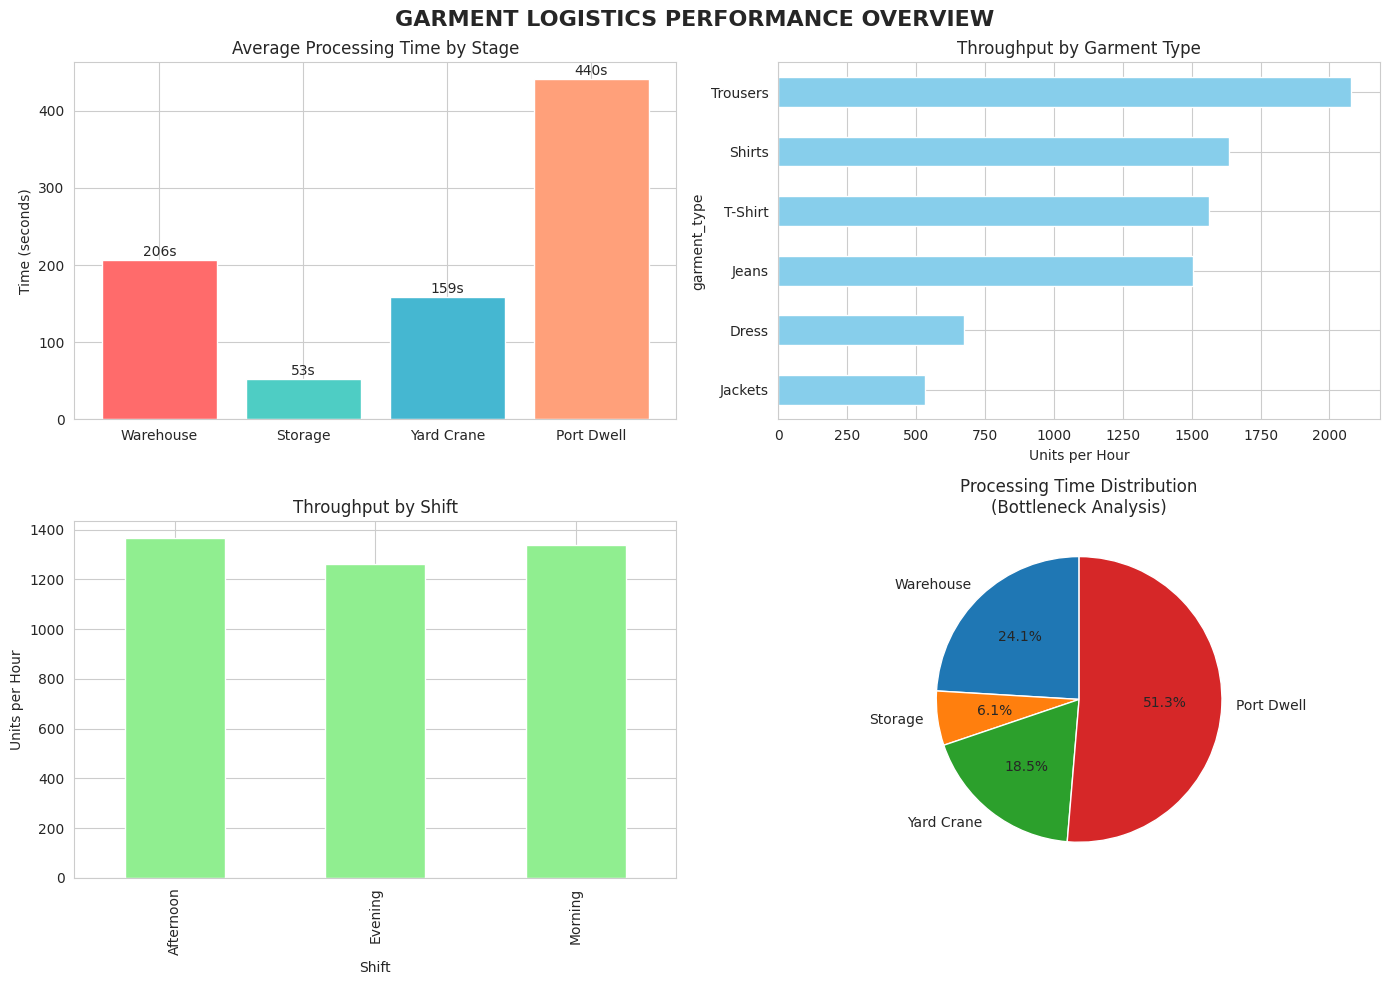


BOTTLENECK IDENTIFICATION
 PRIMARY BOTTLENECK: Port Dwell
   Average Time: 440.4 seconds
   Percentage of Total: 51.3%

Ranking of stages by time:
   Port Dwell: 440.4s (51.3%)
   Warehouse: 206.4s (24.1%)
   Yard Crane: 158.5s (18.5%)
   Storage: 52.7s (6.1%)

PRODUCTION LINE PERFORMANCE

Production Line Summary:
                 units  total_processing_time  throughput_per_hour
production_line                                                   
Line_Alpha       487.4                  845.3               1599.4
Line_Beta        420.0                  964.3               1771.0
Line_Gamma       263.7                  765.6                610.0

 Best performing line: Line_Beta
   Throughput: 1771.0 units/hour

SHIFT PERFORMANCE COMPARISON

Shift Performance:
           units        total_processing_time throughput_per_hour
            mean    sum                  mean                mean
shift                                                            
Afternoon  399.9  31990          

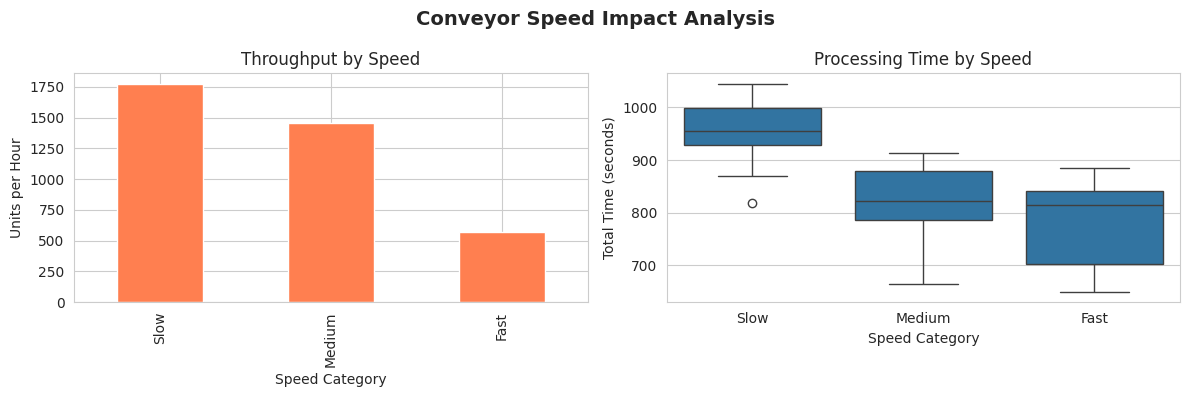


GARMENT TYPE PERFORMANCE

Garment Type Summary:
              units  production_time_sec  throughput_per_hour  \
garment_type                                                    
Trousers      467.7                815.3               2079.5   
Shirts        472.3               1043.1               1636.1   
T-Shirt       502.6               1164.9               1562.7   
Jeans         379.1                910.3               1506.5   
Dress         269.0               1444.0                675.0   
Jackets       257.5               1747.0                534.2   

              total_processing_time  
garment_type                         
Trousers                     1000.5  
Shirts                        880.4  
T-Shirt                       810.3  
Jeans                         933.4  
Dress                         699.8  
Jackets                       842.5  

 Best performing garment: Trousers
 Worst performing garment: Jackets

CORRELATION ANALYSIS

Factors most correlated with Tot

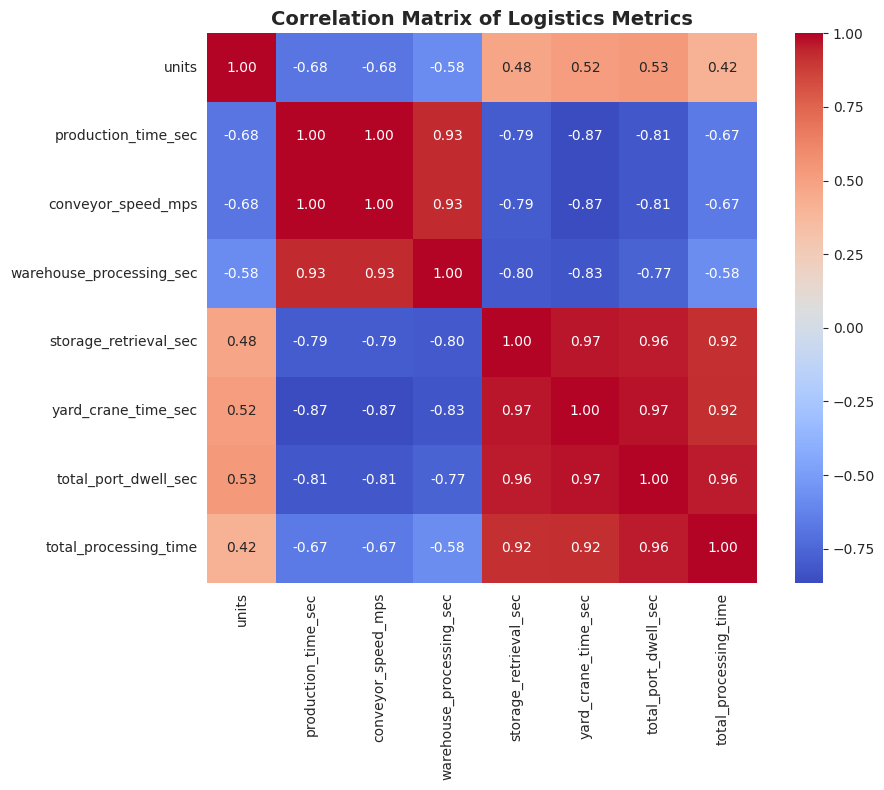


RECOMMENDATIONS
1. BOTTLENECK RESOLUTION: Focus on reducing 'Port Dwell' time
2. CONVEYOR SPEED: Maintain speeds in the 'Slow' range for optimal performance
3. SHIFT OPTIMIZATION: Allocate more resources to 'Afternoon' shift
4. GARMENT TYPE: Optimize processes for 'Jackets' (lowest performer)
5. PRODUCTION LINE: Apply best practices from 'Line_Beta' line to other lines
6. PROCESS IMPROVEMENT: Target the most correlated factors with processing time

KEY METRICS SUMMARY
                       Metric           Value
       Total Batches Analyzed             200
        Total Units Processed           78560
           Average Batch Size       393 units
Average Total Processing Time       858.1 sec
           Average Throughput 1333.6 units/hr
        Best Performing Shift       Afternoon
      Best Performing Garment        Trousers
              Main Bottleneck      Port Dwell

ANALYSIS COMPLETE


In [1]:
# ============================================
# GARMENT LOGISTICS PERFORMANCE ANALYSIS
# Google Colab - File Upload Version
# ============================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from google.colab import files

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ============================================
# 1. UPLOAD AND LOAD THE DATASET
# ============================================

print("=" * 60)
print("GARMENT LOGISTICS PERFORMANCE ANALYSIS")
print("=" * 60)
print("\nPlease upload the 'garment_logistics_200.csv' file")

# Upload file
uploaded = files.upload()

# Load the uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n✅ File '{filename}' loaded successfully!")
print(f"Dataset contains {len(df)} batches")
print(f"Columns: {', '.join(df.columns)}\n")

# ============================================
# 2. DATA EXPLORATION
# ============================================

# Basic statistics
print("--- Basic Statistics ---")
print(df[['units', 'production_time_sec', 'warehouse_processing_sec',
          'total_port_dwell_sec']].describe().round(0))
print("\n" + "=" * 60)

# ============================================
# 3. DEFINE PERFORMANCE OBJECTIVES
# ============================================

print("\nPERFORMANCE OBJECTIVES:")
print("-" * 40)
print("1. MINIMIZE total processing time (warehouse + storage + yard + port)")
print("2. MAXIMIZE throughput (units per hour)")
print("3. IDENTIFY bottlenecks in the logistics chain")
print("4. OPTIMIZE resource allocation (lines, zones, shifts)")
print("5. COMPARE performance across shifts and garment types")
print("=" * 60)

# Calculate key metrics
df['total_processing_time'] = (df['warehouse_processing_sec'] +
                               df['storage_retrieval_sec'] +
                               df['yard_crane_time_sec'] +
                               df['total_port_dwell_sec'])
df['throughput_per_hour'] = df['units'] / (df['production_time_sec'] / 3600)

print(f"\nKEY METRICS:")
print(f"Average Total Processing Time: {df['total_processing_time'].mean():.1f} seconds")
print(f"Average Throughput: {df['throughput_per_hour'].mean():.1f} units/hour")
print(f"Average Batch Size: {df['units'].mean():.0f} units")
print("=" * 60)

# ============================================
# 4. VISUALIZATION - PERFORMANCE OVERVIEW
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GARMENT LOGISTICS PERFORMANCE OVERVIEW', fontsize=16, fontweight='bold')

# Chart 1: Processing Time by Stage
stages = ['warehouse_processing_sec', 'storage_retrieval_sec',
          'yard_crane_time_sec', 'total_port_dwell_sec']
stage_names = ['Warehouse', 'Storage', 'Yard Crane', 'Port Dwell']
stage_means = [df[stage].mean() for stage in stages]
axes[0,0].bar(stage_names, stage_means,
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0,0].set_title('Average Processing Time by Stage', fontsize=12)
axes[0,0].set_ylabel('Time (seconds)')
for i, v in enumerate(stage_means):
    axes[0,0].text(i, v + 5, f'{v:.0f}s', ha='center')

# Chart 2: Throughput by Garment Type
garment_throughput = df.groupby('garment_type')['throughput_per_hour'].mean().sort_values()
garment_throughput.plot(kind='barh', ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Throughput by Garment Type', fontsize=12)
axes[0,1].set_xlabel('Units per Hour')

# Chart 3: Shift Performance
shift_performance = df.groupby('shift')[['throughput_per_hour', 'total_processing_time']].mean()
shift_performance['throughput_per_hour'].plot(kind='bar', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Throughput by Shift', fontsize=12)
axes[1,0].set_ylabel('Units per Hour')
axes[1,0].set_xlabel('Shift')

# Chart 4: Bottleneck Identification - Processing Time Components
bottleneck_df = pd.DataFrame({
    'Stage': stage_names,
    'Time': stage_means,
    'Percentage': [round((v/sum(stage_means))*100, 1) for v in stage_means]
})
axes[1,1].pie(bottleneck_df['Time'], labels=bottleneck_df['Stage'],
              autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Processing Time Distribution\n(Bottleneck Analysis)', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================
# 5. BOTTLENECK ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("BOTTLENECK IDENTIFICATION")
print("=" * 60)

bottleneck_stage = bottleneck_df.loc[bottleneck_df['Time'].idxmax()]
print(f" PRIMARY BOTTLENECK: {bottleneck_stage['Stage']}")
print(f"   Average Time: {bottleneck_stage['Time']:.1f} seconds")
print(f"   Percentage of Total: {bottleneck_stage['Percentage']:.1f}%")
print(f"\nRanking of stages by time:")
for idx, row in bottleneck_df.sort_values('Time', ascending=False).iterrows():
    print(f"   {row['Stage']}: {row['Time']:.1f}s ({row['Percentage']:.1f}%)")

# ============================================
# 6. PRODUCTION LINE ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("PRODUCTION LINE PERFORMANCE")
print("=" * 60)

line_performance = df.groupby('production_line').agg({
    'units': 'mean',
    'total_processing_time': 'mean',
    'throughput_per_hour': 'mean'
}).round(1)

print("\nProduction Line Summary:")
print(line_performance)

best_line = line_performance['throughput_per_hour'].idxmax()
print(f"\n Best performing line: {best_line}")
print(f"   Throughput: {line_performance.loc[best_line, 'throughput_per_hour']:.1f} units/hour")

# ============================================
# 7. SHIFT ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("SHIFT PERFORMANCE COMPARISON")
print("=" * 60)

shift_summary = df.groupby('shift').agg({
    'units': ['mean', 'sum'],
    'total_processing_time': 'mean',
    'throughput_per_hour': 'mean'
}).round(1)

print("\nShift Performance:")
print(shift_summary)

best_shift = df.groupby('shift')['throughput_per_hour'].mean().idxmax()
print(f"\n Best performing shift: {best_shift}")

# ============================================
# 8. CONVEYOR SPEED OPTIMIZATION
# ============================================

print("\n" + "=" * 60)
print("CONVEYOR SPEED OPTIMIZATION")
print("=" * 60)

# Categorize conveyor speed
df['speed_category'] = pd.cut(df['conveyor_speed_mps'],
                              bins=[0, 1.0, 1.4, 2.0],
                              labels=['Slow', 'Medium', 'Fast'])

speed_performance = df.groupby('speed_category', observed=False).agg({
    'throughput_per_hour': 'mean',
    'total_processing_time': 'mean'
}).round(1)

print("\nPerformance by Conveyor Speed:")
print(speed_performance)

best_speed = speed_performance['throughput_per_hour'].idxmax()
print(f"\n Optimal conveyor speed category: {best_speed}")

# Visualize conveyor speed impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Conveyor Speed Impact Analysis', fontsize=14, fontweight='bold')

speed_performance['throughput_per_hour'].plot(kind='bar', ax=ax1, color='coral')
ax1.set_title('Throughput by Speed', fontsize=12)
ax1.set_ylabel('Units per Hour')
ax1.set_xlabel('Speed Category')

sns.boxplot(x='speed_category', y='total_processing_time', data=df, ax=ax2,
            order=['Slow', 'Medium', 'Fast'])
ax2.set_title('Processing Time by Speed', fontsize=12)
ax2.set_ylabel('Total Time (seconds)')
ax2.set_xlabel('Speed Category')

plt.tight_layout()
plt.show()

# ============================================
# 9. GARMENT TYPE OPTIMIZATION
# ============================================

print("\n" + "=" * 60)
print("GARMENT TYPE PERFORMANCE")
print("=" * 60)

garment_summary = df.groupby('garment_type').agg({
    'units': 'mean',
    'production_time_sec': 'mean',
    'throughput_per_hour': 'mean',
    'total_processing_time': 'mean'
}).round(1)

print("\nGarment Type Summary:")
print(garment_summary.sort_values('throughput_per_hour', ascending=False))

best_garment = garment_summary['throughput_per_hour'].idxmax()
worst_garment = garment_summary['throughput_per_hour'].idxmin()
print(f"\n Best performing garment: {best_garment}")
print(f" Worst performing garment: {worst_garment}")

# ============================================
# 10. CORRELATION ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Select numeric columns for correlation
numeric_cols = ['units', 'production_time_sec', 'conveyor_speed_mps',
                'warehouse_processing_sec', 'storage_retrieval_sec',
                'yard_crane_time_sec', 'total_port_dwell_sec', 'total_processing_time']
correlation = df[numeric_cols].corr()

# Find strongest correlations with total_processing_time
target_corr = correlation['total_processing_time'].sort_values(ascending=False)
print("\nFactors most correlated with Total Processing Time:")
print(target_corr[1:].round(3))

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Logistics Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 11. RECOMMENDATIONS
# ============================================

print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)

recommendations = [
    f"1. BOTTLENECK RESOLUTION: Focus on reducing '{bottleneck_stage['Stage']}' time",
    f"2. CONVEYOR SPEED: Maintain speeds in the '{best_speed}' range for optimal performance",
    f"3. SHIFT OPTIMIZATION: Allocate more resources to '{best_shift}' shift",
    f"4. GARMENT TYPE: Optimize processes for '{worst_garment}' (lowest performer)",
    f"5. PRODUCTION LINE: Apply best practices from '{best_line}' line to other lines",
    f"6. PROCESS IMPROVEMENT: Target the most correlated factors with processing time"
]

for rec in recommendations:
    print(rec)

print("\n" + "=" * 60)
print("KEY METRICS SUMMARY")
print("=" * 60)

# Summary dashboard
summary_df = pd.DataFrame({
    'Metric': [
        'Total Batches Analyzed',
        'Total Units Processed',
        'Average Batch Size',
        'Average Total Processing Time',
        'Average Throughput',
        'Best Performing Shift',
        'Best Performing Garment',
        'Main Bottleneck'
    ],
    'Value': [
        len(df),
        df['units'].sum(),
        f"{df['units'].mean():.0f} units",
        f"{df['total_processing_time'].mean():.1f} sec",
        f"{df['throughput_per_hour'].mean():.1f} units/hr",
        best_shift,
        best_garment,
        bottleneck_stage['Stage']
    ]
})

print(summary_df.to_string(index=False))
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)